# Семинар 3 · От линейной классификации к Word2Vec

**Формат:** управляемая демонстрация на 90 минут. Перед ключевыми запусками сначала сформулируйте прогноз, затем сравните его с результатом.

К концу семинара студент сможет:

- вычислить score, sigmoid и log loss бинарного линейного классификатора;
- объяснить, почему в многоклассовой модели каждой категории соответствует свой вектор весов;
- извлечь пары «центральное слово → контекст» из маленького корпуса;
- увидеть Skip-gram как многоклассовый линейный классификатор с обучаемым входным представлением;
- различить full softmax и negative sampling;
- проверить результат через loss, cosine similarity и ближайших соседей.

> Главный вопрос семинара: **что меняется, если признаки объекта не заданы заранее, а тоже обучаются?**

## Ритм занятия

| Время | Блок | Что предсказать до запуска |
|---:|---|---|
| 0–20 мин | Бинарная классификация | Как знак score и sigmoid связаны с классом? |
| 20–35 мин | Softmax | Что означает строка матрицы весов? |
| 35–50 мин | Корпус и пары | Какие направленные пары создаёт окно? |
| 50–72 мин | Skip-gram | Где находятся признаки слова и веса классов? |
| 72–83 мин | Negative sampling | Какие scores должны вырасти, а какие уменьшиться? |
| 83–90 мин | Проверка представлений | Что loss гарантирует, а что — нет? |

Правило для каждой демонстрации: **30 секунд подумать → проголосовать → запустить → объяснить**.

Все данные встроены в notebook. Нужны только `numpy` и `matplotlib`; сетевой доступ не требуется.

## 1. Один score — бинарное решение

Начнём с уже знакомой модели:

$$
s(\mathbf x)=\mathbf w^\mathsf T\mathbf x+b,
\qquad
p(y=1\mid\mathbf x)=\sigma(s)=\frac{1}{1+e^{-s}}.
$$

Граница решения задаётся условием $s(\mathbf x)=0$. Вероятность $p=0.5$ лежит на той же границе.

Создадим маленькую воспроизводимую выборку с двумя признаками. Метки используются только для обучения и проверки; на графике они показаны цветом.

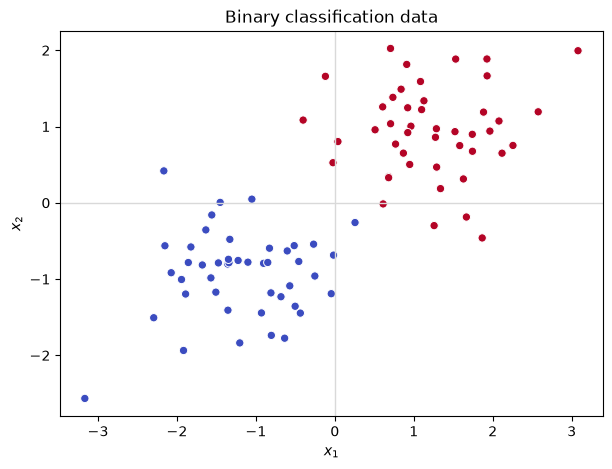

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SEED = 20260921
rng = np.random.default_rng(SEED)
validation_dir = Path("validation")
validation_dir.mkdir(exist_ok=True)

negative = rng.normal(loc=(-1.3, -0.8), scale=(0.65, 0.55), size=(45, 2))
positive = rng.normal(loc=(1.2, 0.9), scale=(0.65, 0.55), size=(45, 2))
X = np.vstack([negative, positive])
y = np.concatenate([np.zeros(len(negative)), np.ones(len(positive))])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="white", linewidth=0.7)
ax.axhline(0, color="0.85", linewidth=1)
ax.axvline(0, color="0.85", linewidth=1)
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Binary classification data")
plt.show()

### Один объект на бумаге

Пусть $\mathbf w=(1.1,0.7)^\mathsf T$, $b=-0.2$, а $\mathbf x=(0.8,-0.1)^\mathsf T$.

**До запуска:**

1. Каков знак score?
2. Больше или меньше $0.5$ будет вероятность класса 1?
3. Изменится ли класс, если умножить одновременно $\mathbf w$ и $b$ на положительную константу? А вероятность?

In [2]:
def sigmoid(value):
    value = np.asarray(value, dtype=float)
    return np.where(
        value >= 0,
        1.0 / (1.0 + np.exp(-value)),
        np.exp(value) / (1.0 + np.exp(value)),
    )


x_demo = np.array([0.8, -0.1])
w_demo = np.array([1.1, 0.7])
b_demo = -0.2
score_demo = x_demo @ w_demo + b_demo
probability_demo = sigmoid(score_demo)

print(f"score = {score_demo:.3f}")
print(f"P(y=1|x) = {probability_demo:.3f}")
print(f"predicted class = {int(probability_demo >= 0.5)}")

assert np.isclose(score_demo, 0.61)
assert probability_demo > 0.5

score = 0.610
P(y=1|x) = 0.648
predicted class = 1


### Обучение: likelihood превращается в log loss

Для наблюдения $(\mathbf x^{(i)},y^{(i)})$ бинарная потеря равна

$$
\ell_i=-y^{(i)}\log p_i-(1-y^{(i)})\log(1-p_i).
$$

Её производная по score особенно проста: $\partial\ell_i/\partial s_i=p_i-y^{(i)}$.
Значит, ошибка проходит через линейный score к $\mathbf w$ и $b$.

**До запуска:** loss должен убывать монотонно или обязан лишь в среднем становиться меньше? Что произойдёт при слишком большом шаге?

In [3]:
def binary_cross_entropy(target, probability):
    probability = np.clip(probability, 1e-12, 1 - 1e-12)
    return -np.mean(target * np.log(probability) + (1 - target) * np.log(1 - probability))


w = np.zeros(X.shape[1])
b = 0.0
learning_rate = 0.35
loss_history = []

for _ in range(350):
    scores = X @ w + b
    probabilities = sigmoid(scores)
    loss_history.append(binary_cross_entropy(y, probabilities))
    score_gradient = probabilities - y
    w -= learning_rate * (X.T @ score_gradient) / len(X)
    b -= learning_rate * score_gradient.mean()

final_probabilities = sigmoid(X @ w + b)
predictions = (final_probabilities >= 0.5).astype(int)
accuracy = np.mean(predictions == y)

print(f"loss: {loss_history[0]:.4f} -> {loss_history[-1]:.4f}")
print(f"training accuracy: {accuracy:.3f}")
print(f"w = {w.round(3)}, b = {b:.3f}")

assert loss_history[-1] < 0.25 * loss_history[0]
assert accuracy > 0.95

loss: 0.6931 -> 0.0213
training accuracy: 1.000
w = [2.951 3.123], b = -0.078


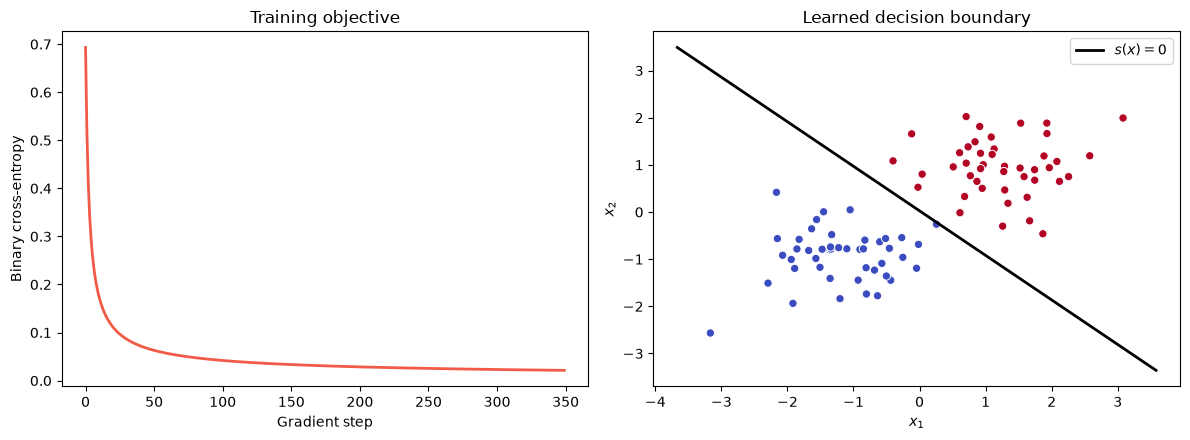

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(loss_history, color="#F05A47", linewidth=2)
axes[0].set(xlabel="Gradient step", ylabel="Binary cross-entropy", title="Training objective")

axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="white", linewidth=0.7)
x_line = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
y_line = -(w[0] * x_line + b) / w[1]
axes[1].plot(x_line, y_line, color="black", linewidth=2, label="$s(x)=0$")
axes[1].set(xlabel="$x_1$", ylabel="$x_2$", title="Learned decision boundary")
axes[1].legend()
fig.tight_layout()
fig.savefig(validation_dir / "binary_classifier.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. От одного класса к словарю классов

В многоклассовой модели у каждого класса $c$ есть свой вектор весов $\mathbf u_c$ и свой score:

$$
z_c=\mathbf u_c^\mathsf T\mathbf x+b_c,
\qquad
p(c\mid\mathbf x)=\frac{e^{z_c}}{\sum_j e^{z_j}}.
$$

Строки матрицы $\mathbf U$ — это веса классов. Softmax превращает все scores в одно распределение вероятностей, а cross-entropy для правильного класса $y$ равна $-\log p(y\mid\mathbf x)$.

**До запуска:** изменится ли softmax, если прибавить одну и ту же константу ко всем scores?

In [5]:
def softmax(values, axis=-1):
    values = np.asarray(values, dtype=float)
    shifted = values - np.max(values, axis=axis, keepdims=True)
    exponentials = np.exp(shifted)
    return exponentials / exponentials.sum(axis=axis, keepdims=True)


x_multi = np.array([1.2, -0.4])
U_demo = np.array([
    [1.0, 0.2],
    [-0.3, 0.8],
    [0.1, -1.1],
])
class_names = np.array(["кот", "яблоко", "поезд"])
scores_multi = U_demo @ x_multi
probabilities_multi = softmax(scores_multi)
target_index = 0
loss_multi = -np.log(probabilities_multi[target_index])

for name, score, probability in zip(class_names, scores_multi, probabilities_multi):
    print(f"{name:7s}: score={score: .3f}, probability={probability:.3f}")
print(f"cross-entropy for target '{class_names[target_index]}': {loss_multi:.3f}")

assert np.isclose(probabilities_multi.sum(), 1.0)
assert np.allclose(softmax(scores_multi), softmax(scores_multi + 100.0))

кот    : score= 1.120, probability=0.576
яблоко : score=-0.680, probability=0.095
поезд  : score= 0.560, probability=0.329
cross-entropy for target 'кот': 0.552


## 3. Где взять признаки слова?

Для обычного классификатора вектор $\mathbf x$ дан заранее. Для слова его можно начать с one-hot-вектора, но такой вектор не кодирует сходство: любые два разных слова одинаково ортогональны.

Word2Vec обучает таблицу входных векторов $\mathbf E$. Умножение one-hot-вектора слова на $\mathbf E$ просто выбирает одну строку:

$$
\operatorname{onehot}(w)^\mathsf T\mathbf E=\mathbf e_w.
$$

Чтобы получить обучающие примеры, превращаем корпус в направленные пары:

$$
(\text{центральное слово},\text{слово из окна}).
$$

Используем искусственный корпус из лекции. Группы заданы только при составлении корпуса; их названия не входят в loss.

In [6]:
groups = {
    "animals": ["кот", "пёс", "волк", "лиса", "медведь"],
    "fruit": ["яблоко", "груша", "слива", "вишня", "персик"],
    "transport": ["поезд", "автобус", "трамвай", "метро", "такси"],
}

corpus = [
    ["кот", "пёс", "волк", "лиса", "медведь"],
    ["медведь", "волк", "кот", "лиса", "пёс"],
    ["лиса", "медведь", "пёс", "кот", "волк"],
    ["волк", "лиса", "кот", "медведь", "пёс"],
    ["яблоко", "груша", "слива", "вишня", "персик"],
    ["персик", "слива", "яблоко", "вишня", "груша"],
    ["вишня", "персик", "груша", "яблоко", "слива"],
    ["слива", "вишня", "яблоко", "персик", "груша"],
    ["поезд", "автобус", "трамвай", "метро", "такси"],
    ["такси", "трамвай", "поезд", "метро", "автобус"],
    ["метро", "такси", "автобус", "поезд", "трамвай"],
    ["трамвай", "метро", "поезд", "такси", "автобус"],
]

words = [word for group_words in groups.values() for word in group_words]
word_to_index = {word: index for index, word in enumerate(words)}
window_size = 2


def extract_pairs(sentences, window):
    result = []
    for sentence in sentences:
        for center_position, center_word in enumerate(sentence):
            left = max(0, center_position - window)
            right = min(len(sentence), center_position + window + 1)
            for context_position in range(left, right):
                if context_position != center_position:
                    result.append((center_word, sentence[context_position]))
    return result


pairs = extract_pairs(corpus, window_size)
print(f"vocabulary size: {len(words)}")
print(f"directed positive pair occurrences: {len(pairs)}")
print("first 12 pairs:", pairs[:12])

assert len(words) == 15
assert len(pairs) == 168
assert ("кот", "пёс") in pairs and ("пёс", "кот") in pairs

vocabulary size: 15
directed positive pair occurrences: 168
first 12 pairs: [('кот', 'пёс'), ('кот', 'волк'), ('пёс', 'кот'), ('пёс', 'волк'), ('пёс', 'лиса'), ('волк', 'кот'), ('волк', 'пёс'), ('волк', 'лиса'), ('волк', 'медведь'), ('лиса', 'пёс'), ('лиса', 'волк'), ('лиса', 'медведь')]


### Сначала посмотрим на наблюдаемые данные

Матрица $\mathbf C$ считает, сколько раз контекст $c$ появился рядом с центральным словом $w$.
Она ещё не является embedding и не является целевой функцией Word2Vec. Это только способ увидеть, откуда берётся обучающий сигнал.

**До запуска:** где должны появиться ненулевые блоки? Почему нулевой count не означает, что два слова «несовместимы в языке»?

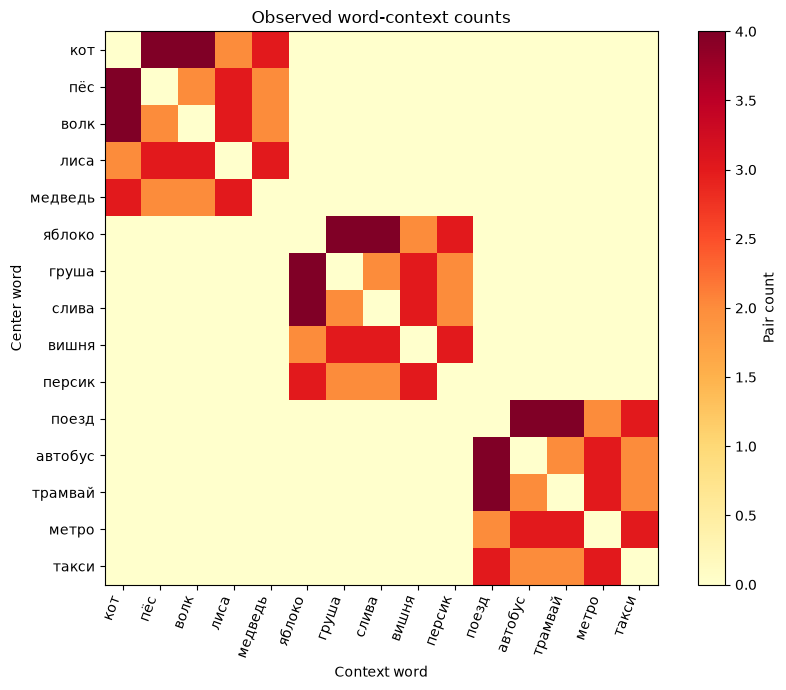

In [7]:
V = len(words)
counts = np.zeros((V, V), dtype=float)
for center_word, context_word in pairs:
    counts[word_to_index[center_word], word_to_index[context_word]] += 1

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(counts, cmap="YlOrRd")
ax.set_xticks(range(V), words, rotation=70, ha="right")
ax.set_yticks(range(V), words)
ax.set(xlabel="Context word", ylabel="Center word", title="Observed word-context counts")
fig.colorbar(image, ax=ax, label="Pair count")
fig.tight_layout()
fig.savefig(validation_dir / "context_counts.png", dpi=150, bbox_inches="tight")
plt.show()

assert np.count_nonzero(counts[:5, 5:]) == 0
assert np.count_nonzero(counts[5:10, :5]) == 0

## 4. Skip-gram — тот же классификатор, но вход тоже обучается

Для центрального слова $w$ выбираем строку $\mathbf e_w$ из таблицы $\mathbf E$.
Каждое возможное контекстное слово $c$ имеет собственный вектор $\mathbf u_c$ в таблице $\mathbf U$:

$$
z_c=\mathbf u_c^\mathsf T\mathbf e_w,
\qquad
p(c\mid w)=\operatorname{softmax}(\mathbf U\mathbf e_w)_c.
$$

Это многоклассовая линейная классификация контекста. Новая часть — вектор признаков $\mathbf e_w$ тоже является параметром.

Важно: совместное обучение $\mathbf E$ и $\mathbf U$ — билинейная параметризация. В отличие от обычной логистической регрессии с фиксированными признаками, задача в целом не обязана быть выпуклой.

In [8]:
embedding_size = 2
model_rng = np.random.default_rng(SEED)
E = model_rng.normal(0, 0.25, size=(V, embedding_size))
U = model_rng.normal(0, 0.25, size=(V, embedding_size))
E_initial = E.copy()


def skipgram_loss_and_gradients(input_vectors, context_vectors, pair_counts, l2=1e-4):
    scores = input_vectors @ context_vectors.T
    probabilities = softmax(scores, axis=1)
    row_totals = pair_counts.sum(axis=1, keepdims=True)
    total_pairs = pair_counts.sum()
    data_loss = -np.sum(pair_counts * np.log(np.clip(probabilities, 1e-12, 1.0))) / total_pairs
    regularization = 0.5 * l2 * (np.sum(input_vectors ** 2) + np.sum(context_vectors ** 2))
    score_gradient = (probabilities * row_totals - pair_counts) / total_pairs
    input_gradient = score_gradient @ context_vectors + l2 * input_vectors
    context_gradient = score_gradient.T @ input_vectors + l2 * context_vectors
    return data_loss + regularization, input_gradient, context_gradient


initial_loss, _, _ = skipgram_loss_and_gradients(E, U, counts)
print(f"initial full-softmax loss: {initial_loss:.4f}")
print(f"uniform baseline log(V): {np.log(V):.4f}")

assert np.isclose(initial_loss, np.log(V), atol=0.2)

initial full-softmax loss: 2.7061
uniform baseline log(V): 2.7081


### Обучаем обе таблицы

Для быстрого воспроизводимого опыта используем Adam и точный градиент по всей маленькой матрице пар. Это не production-реализация Word2Vec: настоящий словарь намного больше, поэтому полный softmax дорог и часто заменяется другими целями.

**До запуска:** loss может уменьшиться, если двигать только $\mathbf U$? А только $\mathbf E$? Почему в Word2Vec нужны обе таблицы?

In [9]:
def adam_update(parameter, gradient, first_moment, second_moment, step, lr=0.08):
    beta1, beta2, epsilon = 0.9, 0.999, 1e-8
    first_moment = beta1 * first_moment + (1 - beta1) * gradient
    second_moment = beta2 * second_moment + (1 - beta2) * gradient ** 2
    first_unbiased = first_moment / (1 - beta1 ** step)
    second_unbiased = second_moment / (1 - beta2 ** step)
    parameter = parameter - lr * first_unbiased / (np.sqrt(second_unbiased) + epsilon)
    return parameter, first_moment, second_moment


m_E = np.zeros_like(E)
v_E = np.zeros_like(E)
m_U = np.zeros_like(U)
v_U = np.zeros_like(U)
skipgram_history = []

for step in range(1, 1201):
    loss, gradient_E, gradient_U = skipgram_loss_and_gradients(E, U, counts)
    skipgram_history.append(loss)
    E, m_E, v_E = adam_update(E, gradient_E, m_E, v_E, step)
    U, m_U, v_U = adam_update(U, gradient_U, m_U, v_U, step)

final_loss, _, _ = skipgram_loss_and_gradients(E, U, counts)
print(f"full-softmax loss: {initial_loss:.4f} -> {final_loss:.4f}")

assert final_loss < 0.7 * initial_loss
assert np.isfinite(E).all() and np.isfinite(U).all()

full-softmax loss: 2.7061 -> 1.5003


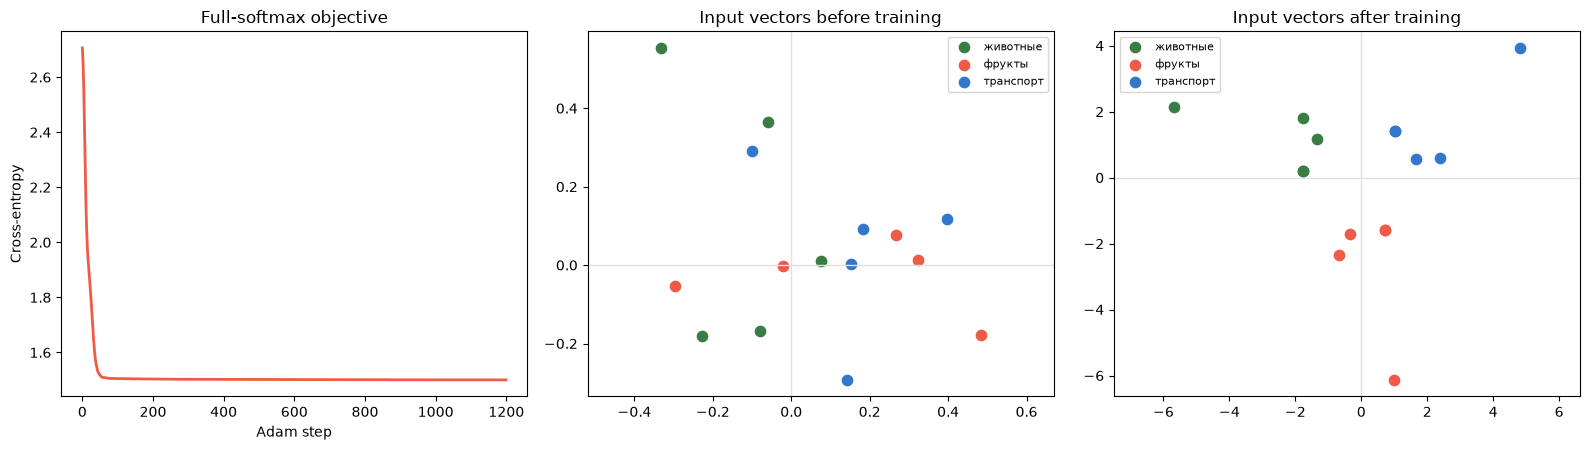

mean cosine within constructed groups: 0.894
mean cosine across constructed groups: -0.458


In [10]:
def cosine_matrix(vectors):
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    normalized = vectors / np.clip(norms, 1e-12, None)
    return normalized @ normalized.T


group_colors = {"animals": "#3A7D44", "fruit": "#F05A47", "transport": "#3377CC"}
group_names = {"animals": "животные", "fruit": "фрукты", "transport": "транспорт"}
word_group = {word: group for group, group_words in groups.items() for word in group_words}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
axes[0].plot(skipgram_history, color="#F05A47", linewidth=2)
axes[0].set(xlabel="Adam step", ylabel="Cross-entropy", title="Full-softmax objective")

for ax, vectors, title in [
    (axes[1], E_initial, "Input vectors before training"),
    (axes[2], E, "Input vectors after training"),
]:
    shown_groups = set()
    for index, word in enumerate(words):
        group = word_group[word]
        label = group_names[group] if group not in shown_groups else None
        ax.scatter(vectors[index, 0], vectors[index, 1], color=group_colors[group], s=55, label=label)
        shown_groups.add(group)
    ax.axhline(0, color="0.88", linewidth=1)
    ax.axvline(0, color="0.88", linewidth=1)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(fontsize=8, loc="best")

fig.tight_layout()
fig.savefig(validation_dir / "skipgram_training.png", dpi=150, bbox_inches="tight")
plt.show()

similarities = cosine_matrix(E)
same_group = []
different_group = []
for i in range(V):
    for j in range(i + 1, V):
        target = same_group if word_group[words[i]] == word_group[words[j]] else different_group
        target.append(similarities[i, j])

print(f"mean cosine within constructed groups: {np.mean(same_group):.3f}")
print(f"mean cosine across constructed groups: {np.mean(different_group):.3f}")
assert np.mean(same_group) > np.mean(different_group) + 0.5

### Ближайшие соседи — отдельная проверка, не training loss

Word2Vec обучался предсказывать контекст через dot products $\mathbf u_c^\mathsf T\mathbf e_w$.
После обучения мы часто сравниваем **входные** векторы слов через cosine similarity:

$$
\cos(\mathbf e_a,\mathbf e_b)=
\frac{\mathbf e_a^\mathsf T\mathbf e_b}{\|\mathbf e_a\|_2\|\mathbf e_b\|_2}.
$$

Это правило retrieval, а не оптимизируемая выше cross-entropy.

In [11]:
def nearest_words(query, k=4):
    query_index = word_to_index[query]
    order = np.argsort(-similarities[query_index])
    return [(words[index], similarities[query_index, index]) for index in order if index != query_index][:k]


for query in ["кот", "яблоко", "поезд"]:
    formatted = ", ".join(f"{word} ({value:.2f})" for word, value in nearest_words(query))
    print(f"{query:7s} -> {formatted}")

assert all(word_group[word] == "animals" for word, _ in nearest_words("кот"))
assert all(word_group[word] == "fruit" for word, _ in nearest_words("яблоко"))
assert all(word_group[word] == "transport" for word, _ in nearest_words("поезд"))

кот     -> лиса (1.00), медведь (0.91), пёс (0.77), волк (0.77)
яблоко  -> вишня (1.00), персик (0.90), груша (0.76), слива (0.76)
поезд   -> метро (1.00), такси (0.90), трамвай (0.77), автобус (0.77)


## 5. Negative sampling — другая задача классификации

Полный softmax сравнивает правильный контекст со всем словарём. Negative sampling формирует другую бинарную задачу:

- наблюдаемая пара $(w,c)$ получает метку $y=1$;
- выбранные шумовые пары $(w,n_i)$ получают метку $y=0$.

Для score $s=\mathbf u^\mathsf T\mathbf e_w$ используется та же бинарная loss, что в начале семинара, и та же производная:

$$
\frac{\partial\ell}{\partial s}=\sigma(s)-y.
$$

**До запуска:** в каком направлении loss просит изменить score положительной пары? А scores выбранных отрицательных пар?

Это утверждение относится к локальной производной по каждому score. Поскольку один центральный вектор участвует сразу в нескольких парах, после общего шага по параметрам каждый отдельный score не обязан измениться монотонно: градиенты взаимодействуют.

In [12]:
center = word_to_index["кот"]
candidate_words = ["пёс", "яблоко", "поезд"]
candidate_indices = np.array([word_to_index[word] for word in candidate_words])
labels = np.array([1.0, 0.0, 0.0])

center_vector = E[center].copy()
candidate_vectors = U[candidate_indices].copy()
scores_before = candidate_vectors @ center_vector
probabilities_before = sigmoid(scores_before)
score_gradients = probabilities_before - labels
score_step = 0.5
independent_score_step = scores_before - score_step * score_gradients

for word, label, before, gradient, after in zip(
    candidate_words, labels, scores_before, score_gradients, independent_score_step
):
    requested_direction = "increase" if -gradient > 0 else "decrease"
    print(
        f"pair (кот, {word:7s}), y={int(label)}: "
        f"score={before: .3f}, dL/ds={gradient: .6f}, requested={requested_direction}, "
        f"independent score step -> {after: .6f}"
    )

assert score_gradients[0] < 0
assert np.all(score_gradients[1:] > 0)
assert independent_score_step[0] > scores_before[0]
assert np.all(independent_score_step[1:] < scores_before[1:])

pair (кот, пёс    ), y=1: score= 7.960, dL/ds=-0.000349, requested=increase, independent score step ->  7.960415
pair (кот, яблоко ), y=0: score=-8.342, dL/ds= 0.000238, requested=decrease, independent score step -> -8.341951
pair (кот, поезд  ), y=0: score= 2.123, dL/ds= 0.893130, requested=decrease, independent score step ->  1.676556


## 6. Что именно установил эксперимент

**Установлено для этого запуска:**

- бинарная log loss уменьшилась, и линейная граница разделила синтетические классы;
- full-softmax Skip-gram loss уменьшилась;
- на специально сконструированном корпусе слова из заданных групп получили более близкие входные векторы;
- локальные производные negative sampling требуют увеличить score положительной пары и уменьшить scores выбранных отрицательных пар; общий шаг по разделяемым векторам может смешивать эти влияния.

**Из этого не следует:**

- что маленький корпус моделирует естественный язык;
- что Word2Vec гарантирует «истинную» семантику;
- что cosine является training loss;
- что ненаблюдаемая пара лингвистически невозможна;
- что совместное обучение двух таблиц является выпуклой задачей.

Финальная формула-мост:

$$
\underbrace{\mathbf u_c^\mathsf T\mathbf x}_{\text{линейный классификатор с фиксированными признаками}}
\quad\longrightarrow\quad
\underbrace{\mathbf u_c^\mathsf T\mathbf e_w}_{\text{Skip-gram: признаки слова тоже обучаются}}.
$$

## Резервные вопросы

1. Почему прибавление одной константы ко всем logits не меняет softmax?
2. Почему две таблицы $\mathbf E$ и $\mathbf U$ не обязаны совпадать?
3. Чем «сосед в текстовом окне» отличается от «соседа в embedding space»?
4. Почему negative sampling не даёт нормированную вероятность $p(c\mid w)$ по всему словарю?
5. Что изменится, если увеличить размер окна или сделать частые слова намного чаще остальных?